# Pengujian Otomatis Sistem NLP Rule-Based & Fuzzy String Matching

Notebook ini melakukan **pengujian otomatis** terhadap sistem NLP berbasis **Rule-Based** dan **Fuzzy String Matching** yang digunakan pada chatbot penjualan UMKM.

Seluruh hasil prediksi berasal dari **pembacaan sistem yang sebenarnya** melalui fungsi `proses_nlp()`. Tidak ada prediksi manual, tidak ada modifikasi output, dan tidak ada penyesuaian terhadap Ground Truth.

---

### Tujuan Pengujian

1. **Identifikasi Intent** — Menguji kemampuan sistem mengenali maksud pengguna.
2. **Ekstraksi Entitas** — Menguji kemampuan sistem mengekstrak informasi dari teks.

### Metode Evaluasi

| Metrik | Library |
|---|---|
| Confusion Matrix | `sklearn.metrics` |
| Accuracy | `sklearn.metrics` |
| Precision (macro) | `sklearn.metrics` |
| Recall (macro) | `sklearn.metrics` |
| F1-score (macro) | `sklearn.metrics` |

### Library yang Digunakan

- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

---
## 1. Import Library & Inisialisasi Sistem

In [1]:
import sys
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Pastikan root project ada di sys.path agar modul NLP dapat diimpor
PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Import fungsi NLP dari sistem yang sebenarnya
from nlp.processor import proses_nlp

# Konfigurasi tampilan
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 220)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("=" * 60)
print("INISIALISASI SISTEM")
print("=" * 60)
print(f"Project Root  : {PROJECT_ROOT}")
print(f"Waktu Eksekusi: {datetime.now().strftime('%d-%m-%Y %H:%M:%S')}")
print(f"Fungsi NLP    : proses_nlp() dari nlp.processor")
print("\n✅ Seluruh library dan modul NLP berhasil dimuat.")

INISIALISASI SISTEM
Project Root  : C:\Users\FINN\Documents\BOT
Waktu Eksekusi: 26-06-2026 19:55:17
Fungsi NLP    : proses_nlp() dari nlp.processor

✅ Seluruh library dan modul NLP berhasil dimuat.


---
## 2. Dataset Pengujian (20 Data Uji)

In [2]:
test_inputs = [
    "Halo bot",
    "Selamat pagi",
    "Cek penjualan hari ini",
    "Total uang masuk hari ini",
    "Tampilkan semua transaksi",
    "Tampilkan transaksi kemarin",
    "Tampilkan transaksi tanggal 21",
    "Cek hutang pak andi",
    "Tampilkan tagihan",
    "Berapa harga brownis",
    "Tambah barang brownis harga 2500 per bungkus",
    "Edit harga permen jadi 14000",
    "Hapus transaksi pak ardi",
    "Update transaksi udin jadi lunas",
    "Hari ini Budi ambil bembeng 40 ctn lunas tunai",
    "Kemarin Udin ambil meses 20 ctn dicicil 200000 tf",
    "06-2026 Nama : Budi budis bembeng 40 ctn meses 20 ctn willo 100 ctn",
    "21/04/2026 Andi ambil permen 10 dus dicicil 50000 transfer",
    "Zio bayar hutang 270000 transfer",
    "Tambahan bayar pak andi 50rb tunai"
]

print(f"Total data uji: {len(test_inputs)}")
print("-" * 60)
for i, inp in enumerate(test_inputs, 1):
    print(f"  [{i:02d}] {inp}")

Total data uji: 20
------------------------------------------------------------
  [01] Halo bot
  [02] Selamat pagi
  [03] Cek penjualan hari ini
  [04] Total uang masuk hari ini
  [05] Tampilkan semua transaksi
  [06] Tampilkan transaksi kemarin
  [07] Tampilkan transaksi tanggal 21
  [08] Cek hutang pak andi
  [09] Tampilkan tagihan
  [10] Berapa harga brownis
  [11] Tambah barang brownis harga 2500 per bungkus
  [12] Edit harga permen jadi 14000
  [13] Hapus transaksi pak ardi
  [14] Update transaksi udin jadi lunas
  [15] Hari ini Budi ambil bembeng 40 ctn lunas tunai
  [16] Kemarin Udin ambil meses 20 ctn dicicil 200000 tf
  [17] 06-2026 Nama : Budi budis bembeng 40 ctn meses 20 ctn willo 100 ctn
  [18] 21/04/2026 Andi ambil permen 10 dus dicicil 50000 transfer
  [19] Zio bayar hutang 270000 transfer
  [20] Tambahan bayar pak andi 50rb tunai


---
## 3. Ground Truth

Ground Truth berisi label yang benar untuk setiap input pengujian. Digunakan **hanya sebagai pembanding** terhadap hasil prediksi sistem.

Komponen Ground Truth:
- **Intent**: Label intent yang diharapkan
- **Entitas**: tanggal, pelanggan, barang, jumlah, satuan, status, nominal, metode_pembayaran
- Jika suatu entitas tidak ada, diisi dengan `None`

In [3]:
# Tanggal dinamis — dihitung saat notebook dijalankan
hari_ini = datetime.now()
tgl_hari_ini = hari_ini.strftime("%d-%m-%Y")
tgl_kemarin = (hari_ini - timedelta(days=1)).strftime("%d-%m-%Y")

# Tanggal 21: jika hari ini sudah lewat tgl 21, maka bulan ini; jika belum, bulan lalu
if 21 > hari_ini.day:
    bln21 = hari_ini.month - 1
    thn21 = hari_ini.year
    if bln21 == 0:
        bln21 = 12
        thn21 -= 1
else:
    bln21 = hari_ini.month
    thn21 = hari_ini.year
tgl_21 = f"21-{bln21:02d}-{thn21}"

ground_truth = [
    # 1. Halo bot
    {"intent": "Chit_Chat",
     "tanggal": None, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 2. Selamat pagi
    {"intent": "Chit_Chat",
     "tanggal": None, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 3. Cek penjualan hari ini
    {"intent": "Read_Analitik_Penjualan",
     "tanggal": tgl_hari_ini, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 4. Total uang masuk hari ini
    {"intent": "Read_Analitik_Penjualan",
     "tanggal": tgl_hari_ini, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 5. Tampilkan semua transaksi
    {"intent": "Read_Transaksi_Spesifik",
     "tanggal": None, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 6. Tampilkan transaksi kemarin
    {"intent": "Read_Transaksi_Spesifik",
     "tanggal": tgl_kemarin, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 7. Tampilkan transaksi tanggal 21
    {"intent": "Read_Transaksi_Spesifik",
     "tanggal": tgl_21, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 8. Cek hutang pak andi
    {"intent": "Read_Analitik_Hutang",
     "tanggal": None, "pelanggan": "Pak Andi", "barang": None, "jumlah": None,
     "satuan": None, "status": "Hutang", "nominal": None, "metode_pembayaran": None},

    # 9. Tampilkan tagihan
    {"intent": "Read_Analitik_Hutang",
     "tanggal": None, "pelanggan": None, "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 10. Berapa harga brownis
    {"intent": "CRUD_Barang",
     "tanggal": None, "pelanggan": None, "barang": "Brownis", "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 11. Tambah barang brownis harga 2500 per bungkus
    {"intent": "CRUD_Barang",
     "tanggal": None, "pelanggan": None, "barang": "Brownis", "jumlah": None,
     "satuan": "bungkus", "status": None, "nominal": None, "metode_pembayaran": None},

    # 12. Edit harga permen jadi 14000
    {"intent": "CRUD_Barang",
     "tanggal": None, "pelanggan": None, "barang": "Lolipop", "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 13. Hapus transaksi pak ardi
    {"intent": "Update_Delete_Transaksi",
     "tanggal": None, "pelanggan": "Pak Ardi", "barang": None, "jumlah": None,
     "satuan": None, "status": None, "nominal": None, "metode_pembayaran": None},

    # 14. Update transaksi udin jadi lunas
    {"intent": "Update_Delete_Transaksi",
     "tanggal": None, "pelanggan": "Udin", "barang": None, "jumlah": None,
     "satuan": None, "status": "Lunas", "nominal": None, "metode_pembayaran": None},

    # 15. Hari ini Budi ambil bembeng 40 ctn lunas tunai
    {"intent": "Catat_Penjualan_Lunas",
     "tanggal": tgl_hari_ini, "pelanggan": "Budi", "barang": "Bembeng",
     "jumlah": "40", "satuan": "karton", "status": "Lunas",
     "nominal": None, "metode_pembayaran": "Tunai"},

    # 16. Kemarin Udin ambil meses 20 ctn dicicil 200000 tf
    {"intent": "Catat_Penjualan_Cicil",
     "tanggal": tgl_kemarin, "pelanggan": "Udin", "barang": "Meses",
     "jumlah": "20", "satuan": "karton", "status": "Dicicil",
     "nominal": "Rp 200.000", "metode_pembayaran": "Transfer"},

    # 17. 06-2026 Nama : Budi budis bembeng 40 ctn meses 20 ctn willo 100 ctn
    {"intent": "Catat_Penjualan_Lunas",
     "tanggal": "06-2026", "pelanggan": "Budi", "barang": "Bembeng",
     "jumlah": "40", "satuan": "karton", "status": None,
     "nominal": None, "metode_pembayaran": None},

    # 18. 21/04/2026 Andi ambil permen 10 dus dicicil 50000 transfer
    {"intent": "Catat_Penjualan_Cicil",
     "tanggal": "21-04-2026", "pelanggan": "Andi", "barang": "Lolipop",
     "jumlah": "10", "satuan": "dus", "status": "Dicicil",
     "nominal": "Rp 50.000", "metode_pembayaran": "Transfer"},

    # 19. Zio bayar hutang 270000 transfer
    {"intent": "Pelunasan_Hutang",
     "tanggal": None, "pelanggan": "Zio", "barang": None, "jumlah": None,
     "satuan": None, "status": "Dicicil",
     "nominal": "Rp 270.000", "metode_pembayaran": "Transfer"},

    # 20. Tambahan bayar pak andi 50rb tunai
    {"intent": "Pelunasan_Hutang",
     "tanggal": None, "pelanggan": "Pak Andi", "barang": None, "jumlah": None,
     "satuan": None, "status": "Dicicil",
     "nominal": "Rp 50.000", "metode_pembayaran": "Tunai"}
]

# Buat DataFrame Ground Truth
df_gt = pd.DataFrame(ground_truth)
df_gt.insert(0, 'No', range(1, len(df_gt) + 1))
df_gt.insert(1, 'Input', test_inputs)

print("✅ Ground Truth berhasil dibuat.")
print(f"   Jumlah data        : {len(df_gt)}")
print(f"   Jumlah jenis intent: {df_gt['intent'].nunique()}")
print(f"   Jenis entitas      : {len([c for c in df_gt.columns if c not in ['No','Input','intent']])}")
print()
df_gt

✅ Ground Truth berhasil dibuat.
   Jumlah data        : 20
   Jumlah jenis intent: 9
   Jenis entitas      : 8



,No,Input,intent,tanggal,pelanggan,barang,jumlah,satuan,status,nominal,metode_pembayaran
0,1,Halo bot,Chit_Chat,None,None,None,None,None,None,None,None
1,2,Selamat pagi,Chit_Chat,None,None,None,None,None,None,None,None
2,3,Cek penjualan hari ini,Read_Analitik_Penjualan,26-06-2026,None,None,None,None,None,None,None
3,4,Total uang masuk hari ini,Read_Analitik_Penjualan,26-06-2026,None,None,None,None,None,None,None
4,5,Tampilkan semua transaksi,Read_Transaksi_Spesifik,None,None,None,None,None,None,None,None
5,6,Tampilkan transaksi kemarin,Read_Transaksi_Spesifik,25-06-2026,None,None,None,None,None,None,None
6,7,Tampilkan transaksi tanggal 21,Read_Transaksi_Spesifik,21-06-2026,None,None,None,None,None,None,None
7,8,Cek hutang pak andi,Read_Analitik_Hutang,None,Pak Andi,None,None,None,Hutang,None,None
8,9,Tampilkan tagihan,Read_Analitik_Hutang,None,None,None,None,None,None,None,None
9,10,Berapa harga brownis,CRUD_Barang,None,None,Brownis,None,None,None,None,None


---
## 4. Pengujian Sistem — Menjalankan Pipeline NLP yang Sebenarnya

Untuk setiap input, sistem menjalankan seluruh pipeline NLP melalui fungsi `proses_nlp()`:

1. **Normalisasi teks** — Koreksi typo dan slang (`koreksi_teks()`)
2. **Ekstraksi entitas** — Rule-Based + Regex (`ekstrak_entitas()`)
3. **Penentuan intent** — Fuzzy String Matching + Rule-Based (`tentukan_intent()`)

Hasil prediksi disimpan **apa adanya** tanpa modifikasi apapun.

> ⚠️ Jika sistem salah mengenali intent atau entitas, hasil yang salah tetap disimpan.

In [4]:
def jalankan_prediksi(inputs):
    """
    Menjalankan pipeline NLP yang sebenarnya (proses_nlp) untuk setiap input.
    Hasil disimpan apa adanya tanpa modifikasi.
    """
    prediksi_list = []

    for i, teks in enumerate(inputs):
        teks_display = teks[:55] + '...' if len(teks) > 55 else teks
        print(f"  [{i+1:02d}] Memproses: {teks_display}")

        try:
            # ===== MENJALANKAN PIPELINE NLP YANG SEBENARNYA =====
            hasil = proses_nlp(teks)
            # ====================================================

            if hasil and len(hasil) > 0:
                r = hasil[0]  # Ambil hasil utama (pertama)
                intent_pred = r.get("intent", "Unknown")
                ent = r.get("entitas", {})

                # Ekstrak jumlah: pisahkan angka dari satuan
                # Sistem menyimpan JUMLAH dalam format "40 karton" atau "40"
                jumlah_raw = ent.get("JUMLAH")
                jumlah = None
                if jumlah_raw:
                    angka_match = re.search(r'(\d+)', str(jumlah_raw))
                    if angka_match:
                        jumlah = angka_match.group(1)

                prediksi_list.append({
                    "intent": intent_pred,
                    "tanggal": ent.get("TANGGAL"),
                    "pelanggan": ent.get("NAMA"),
                    "barang": ent.get("BARANG"),
                    "jumlah": jumlah,
                    "satuan": ent.get("SATUAN"),
                    "status": ent.get("STATUS"),
                    "nominal": ent.get("NOMINAL_BAYAR"),
                    "metode_pembayaran": ent.get("METODE_PEMBAYARAN")
                })
            else:
                prediksi_list.append({
                    "intent": "Unknown",
                    "tanggal": None, "pelanggan": None, "barang": None,
                    "jumlah": None, "satuan": None, "status": None,
                    "nominal": None, "metode_pembayaran": None
                })

        except Exception as e:
            print(f"       ⚠️ Error pada input [{i+1}]: {e}")
            prediksi_list.append({
                "intent": "ERROR",
                "tanggal": None, "pelanggan": None, "barang": None,
                "jumlah": None, "satuan": None, "status": None,
                "nominal": None, "metode_pembayaran": None
            })

    return prediksi_list


print("=" * 60)
print("MENJALANKAN PIPELINE NLP UNTUK 20 DATA UJI")
print("=" * 60)
print()

prediksi = jalankan_prediksi(test_inputs)

print()
print(f"✅ Prediksi selesai. Total hasil: {len(prediksi)}")
print("   Seluruh hasil berasal dari sistem tanpa modifikasi.")

MENJALANKAN PIPELINE NLP UNTUK 20 DATA UJI

  [01] Memproses: Halo bot
  [02] Memproses: Selamat pagi
  [03] Memproses: Cek penjualan hari ini
  [04] Memproses: Total uang masuk hari ini
  [05] Memproses: Tampilkan semua transaksi
  [06] Memproses: Tampilkan transaksi kemarin
  [07] Memproses: Tampilkan transaksi tanggal 21
  [08] Memproses: Cek hutang pak andi
  [09] Memproses: Tampilkan tagihan
  [10] Memproses: Berapa harga brownis
  [11] Memproses: Tambah barang brownis harga 2500 per bungkus
  [12] Memproses: Edit harga permen jadi 14000
  [13] Memproses: Hapus transaksi pak ardi
  [14] Memproses: Update transaksi udin jadi lunas
  [15] Memproses: Hari ini Budi ambil bembeng 40 ctn lunas tunai


  [16] Memproses: Kemarin Udin ambil meses 20 ctn dicicil 200000 tf


  [17] Memproses: 06-2026 Nama : Budi budis bembeng 40 ctn meses 20 ctn w...
  [18] Memproses: 21/04/2026 Andi ambil permen 10 dus dicicil 50000 trans...
  [19] Memproses: Zio bayar hutang 270000 transfer
  [20] Memproses: Tambahan bayar pak andi 50rb tunai

✅ Prediksi selesai. Total hasil: 20
   Seluruh hasil berasal dari sistem tanpa modifikasi.


---
## 5. Tabel Hasil Prediksi

Tabel berikut membandingkan **Ground Truth** dengan **Prediksi Sistem** secara berdampingan.

> ⚠️ Hasil prediksi ditampilkan **apa adanya** tanpa koreksi apapun.

In [5]:
def format_entitas_ringkas(data_dict):
    """Format dictionary entitas menjadi string ringkas untuk tabel."""
    fields = [
        ('tanggal', 'Tgl'), ('pelanggan', 'Plg'), ('barang', 'Brg'),
        ('jumlah', 'Jml'), ('satuan', 'Sat'), ('status', 'Sts'),
        ('nominal', 'Nom'), ('metode_pembayaran', 'Met')
    ]
    parts = []
    for key, label in fields:
        val = data_dict.get(key)
        if val is not None and str(val).strip() not in ('', 'None'):
            parts.append(f"{label}={val}")
    return ' | '.join(parts) if parts else '—'


# Buat tabel perbandingan
tabel_data = []
for i in range(len(test_inputs)):
    gt = ground_truth[i]
    pred = prediksi[i]

    tabel_data.append({
        'No': i + 1,
        'Input': test_inputs[i],
        'Ground Truth Intent': gt['intent'],
        'Prediksi Intent': pred['intent'],
        'Ground Truth Entitas': format_entitas_ringkas(gt),
        'Prediksi Entitas': format_entitas_ringkas(pred)
    })

df_tabel = pd.DataFrame(tabel_data)

print("=" * 100)
print("TABEL PERBANDINGAN: GROUND TRUTH vs PREDIKSI SISTEM")
print("=" * 100)
print()
df_tabel

TABEL PERBANDINGAN: GROUND TRUTH vs PREDIKSI SISTEM



,No,Input,Ground Truth Intent,Prediksi Intent,Ground Truth Entitas,Prediksi Entitas
0,1,Halo bot,Chit_Chat,Chit_Chat,—,Plg=Halo Bot
1,2,Selamat pagi,Chit_Chat,Chit_Chat,—,Plg=Selamat
2,3,Cek penjualan hari ini,Read_Analitik_Penjualan,Read_Analitik_Penjualan,Tgl=26-06-2026,Tgl=26-06-2026
3,4,Total uang masuk hari ini,Read_Analitik_Penjualan,Read_Analitik_Penjualan,Tgl=26-06-2026,Tgl=26-06-2026 | Sts=Hutang
4,5,Tampilkan semua transaksi,Read_Transaksi_Spesifik,Read_Transaksi_Spesifik,—,—
5,6,Tampilkan transaksi kemarin,Read_Transaksi_Spesifik,Read_Transaksi_Spesifik,Tgl=25-06-2026,Tgl=25-06-2026
6,7,Tampilkan transaksi tanggal 21,Read_Transaksi_Spesifik,Read_Transaksi_Spesifik,Tgl=21-06-2026,Tgl=21-06-2026
7,8,Cek hutang pak andi,Read_Analitik_Hutang,Read_Analitik_Hutang,Plg=Pak Andi | Sts=Hutang,Plg=Pak Andi | Sts=Hutang
8,9,Tampilkan tagihan,Read_Analitik_Hutang,Read_Analitik_Hutang,—,Sts=Hutang
9,10,Berapa harga brownis,CRUD_Barang,CRUD_Barang,Brg=Brownis,Brg=Brownis


In [6]:
# Detail perbandingan per baris untuk analisis mendalam
ENTITY_FIELDS = ['tanggal', 'pelanggan', 'barang', 'jumlah', 'satuan', 'status', 'nominal', 'metode_pembayaran']

print("=" * 100)
print("DETAIL PERBANDINGAN PER INPUT")
print("=" * 100)

for i in range(len(test_inputs)):
    gt = ground_truth[i]
    pred = prediksi[i]

    intent_ok = "✅" if gt['intent'] == pred['intent'] else "❌"

    print(f"\n[{i+1:02d}] {test_inputs[i]}")
    print(f"     Intent     : GT = {gt['intent']:<30s} | Pred = {pred['intent']:<30s} {intent_ok}")

    for field in ENTITY_FIELDS:
        gt_val = str(gt.get(field)) if gt.get(field) is not None else 'None'
        pred_val = str(pred.get(field)) if pred.get(field) is not None else 'None'
        match = "✅" if gt_val == pred_val else "❌"
        print(f"     {field:<20s}: GT = {gt_val:<25s} | Pred = {pred_val:<25s} {match}")

DETAIL PERBANDINGAN PER INPUT

[01] Halo bot
     Intent     : GT = Chit_Chat                      | Pred = Chit_Chat                      ✅
     tanggal             : GT = None                      | Pred = None                      ✅
     pelanggan           : GT = None                      | Pred = Halo Bot                  ❌
     barang              : GT = None                      | Pred = None                      ✅
     jumlah              : GT = None                      | Pred = None                      ✅
     satuan              : GT = None                      | Pred = None                      ✅
     status              : GT = None                      | Pred = None                      ✅
     nominal             : GT = None                      | Pred = None                      ✅
     metode_pembayaran   : GT = None                      | Pred = None                      ✅

[02] Selamat pagi
     Intent     : GT = Chit_Chat                      | Pred = Chit_Chat        

---
## 6. Evaluasi Identifikasi Intent

Membandingkan **Ground Truth Intent** dengan **Prediksi Intent** menggunakan `sklearn.metrics`.

Metrik dihitung dengan `average='macro'` untuk memperlakukan semua kelas secara setara.

In [7]:
# Siapkan data intent
gt_intents = [gt['intent'] for gt in ground_truth]
pred_intents = [p['intent'] for p in prediksi]

# Hitung metrik menggunakan sklearn.metrics
intent_accuracy = accuracy_score(gt_intents, pred_intents)
intent_precision = precision_score(gt_intents, pred_intents, average='macro', zero_division=0)
intent_recall = recall_score(gt_intents, pred_intents, average='macro', zero_division=0)
intent_f1 = f1_score(gt_intents, pred_intents, average='macro', zero_division=0)

print("=" * 70)
print("EVALUASI IDENTIFIKASI INTENT")
print("=" * 70)
print(f"\n  Accuracy  : {intent_accuracy:.4f}  ({intent_accuracy*100:.2f}%)")
print(f"  Precision : {intent_precision:.4f}  ({intent_precision*100:.2f}%)  [macro]")
print(f"  Recall    : {intent_recall:.4f}  ({intent_recall*100:.2f}%)  [macro]")
print(f"  F1-score  : {intent_f1:.4f}  ({intent_f1*100:.2f}%)  [macro]")

# Classification Report
all_intent_labels = sorted(set(gt_intents + pred_intents))

print("\n" + "-" * 70)
print("Classification Report — Identifikasi Intent")
print("-" * 70)
print(classification_report(
    gt_intents, pred_intents,
    labels=all_intent_labels,
    zero_division=0
))

EVALUASI IDENTIFIKASI INTENT

  Accuracy  : 0.9500  (95.00%)
  Precision : 0.9722  (97.22%)  [macro]
  Recall    : 0.9444  (94.44%)  [macro]
  F1-score  : 0.9471  (94.71%)  [macro]

----------------------------------------------------------------------
Classification Report — Identifikasi Intent
----------------------------------------------------------------------
                         precision    recall  f1-score   support

            CRUD_Barang       1.00      1.00      1.00         3
  Catat_Penjualan_Cicil       1.00      1.00      1.00         2
  Catat_Penjualan_Lunas       1.00      1.00      1.00         2
              Chit_Chat       1.00      1.00      1.00         2
       Pelunasan_Hutang       1.00      0.50      0.67         2
   Read_Analitik_Hutang       1.00      1.00      1.00         2
Read_Analitik_Penjualan       1.00      1.00      1.00         2
Read_Transaksi_Spesifik       0.75      1.00      0.86         3
Update_Delete_Transaksi       1.00      1.00  

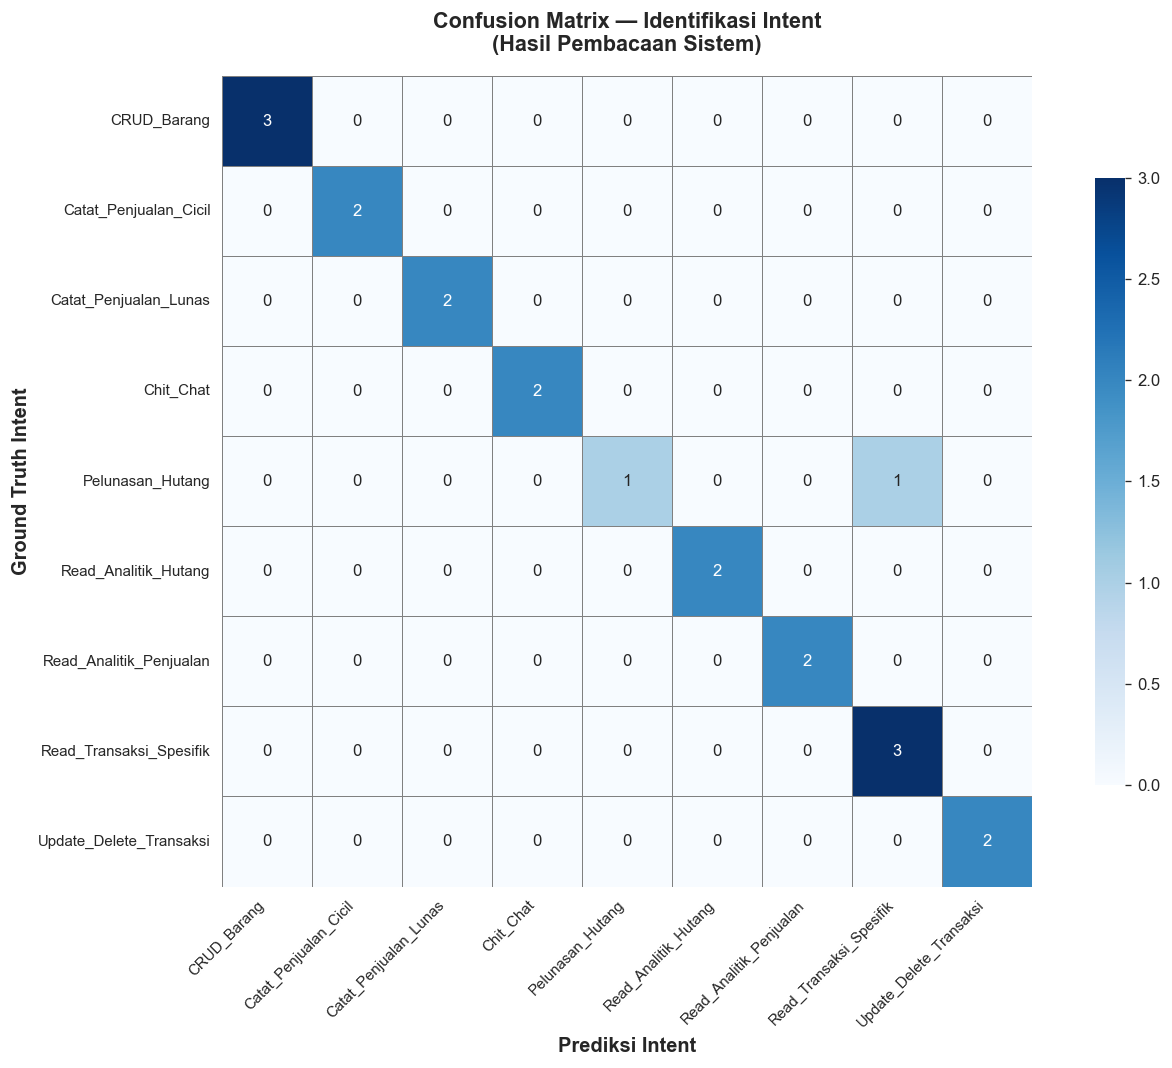

In [8]:
# Heatmap Confusion Matrix — Intent
cm_intent = confusion_matrix(gt_intents, pred_intents, labels=all_intent_labels)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_intent,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=all_intent_labels,
    yticklabels=all_intent_labels,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'shrink': 0.75},
    square=True,
    ax=ax
)
ax.set_xlabel('Prediksi Intent', fontsize=12, fontweight='bold')
ax.set_ylabel('Ground Truth Intent', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix — Identifikasi Intent\n(Hasil Pembacaan Sistem)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Evaluasi Ekstraksi Entitas

Evaluasi dilakukan terhadap **seluruh jenis entitas**:
- tanggal, pelanggan, barang, jumlah, satuan, status, nominal, metode_pembayaran

Metode evaluasi:
- Setiap pasangan (Ground Truth, Prediksi) untuk setiap entitas diklasifikasikan sebagai **Benar** atau **Salah** berdasarkan *exact match*.
- Metrik TP, FP, FN, TN dihitung untuk menentukan Precision, Recall, dan F1-score.

In [9]:
# Normalisasi nilai entitas untuk perbandingan yang adil
def normalize_val(val):
    """Normalisasi nilai entitas ke string untuk perbandingan."""
    if val is None:
        return 'None'
    s = str(val).strip()
    if s.lower() in ('none', '', 'nan', 'false'):
        return 'None'
    return s


# Kumpulkan semua pasangan GT vs Pred untuk seluruh entitas
gt_entity_all = []
pred_entity_all = []
detail_rows = []

for i in range(len(test_inputs)):
    gt = ground_truth[i]
    pred = prediksi[i]

    for field in ENTITY_FIELDS:
        gt_val = normalize_val(gt.get(field))
        pred_val = normalize_val(pred.get(field))

        gt_entity_all.append(gt_val)
        pred_entity_all.append(pred_val)

        detail_rows.append({
            'No': i + 1,
            'Input': test_inputs[i][:45],
            'Entitas': field,
            'GT': gt_val,
            'Pred': pred_val,
            'Cocok': '✅' if gt_val == pred_val else '❌'
        })

# --- Hitung metrik TP, FP, FN, TN ---
# TP = GT non-None DAN Pred non-None DAN GT == Pred (benar terdeteksi, nilai tepat)
# TN = GT None DAN Pred None (benar tidak ada)
# FP = Pred non-None tapi (GT None ATAU GT != Pred) (salah mendeteksi)
# FN = GT non-None tapi (Pred None ATAU GT != Pred) (gagal mendeteksi)

tp = fp = fn = tn = 0
for gv, pv in zip(gt_entity_all, pred_entity_all):
    g_exists = gv != 'None'
    p_exists = pv != 'None'

    if g_exists and p_exists and gv == pv:
        tp += 1
    elif not g_exists and not p_exists:
        tn += 1
    elif p_exists and (not g_exists or gv != pv):
        fp += 1
    elif g_exists and (not p_exists or gv != pv):
        fn += 1

total_pasangan = len(gt_entity_all)
total_cocok = sum(1 for g, p in zip(gt_entity_all, pred_entity_all) if g == p)

entity_accuracy = total_cocok / total_pasangan
entity_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
entity_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
entity_f1 = (2 * entity_precision * entity_recall / (entity_precision + entity_recall)
             if (entity_precision + entity_recall) > 0 else 0)

print("=" * 70)
print("EVALUASI EKSTRAKSI ENTITAS (Keseluruhan)")
print("=" * 70)
print(f"\n  Total pasangan entitas  : {total_pasangan}  (20 input × 8 jenis entitas)")
print(f"  Cocok (exact match)     : {total_cocok}")
print(f"  Tidak cocok             : {total_pasangan - total_cocok}")
print(f"\n  TP = {tp}  (entitas ada & nilai tepat)")
print(f"  TN = {tn}  (entitas tidak ada & memang tidak ada)")
print(f"  FP = {fp}  (sistem mendeteksi tapi salah/tidak seharusnya)")
print(f"  FN = {fn}  (entitas seharusnya ada tapi gagal/salah)")
print(f"\n  Accuracy  : {entity_accuracy:.4f}  ({entity_accuracy*100:.2f}%)")
print(f"  Precision : {entity_precision:.4f}  ({entity_precision*100:.2f}%)")
print(f"  Recall    : {entity_recall:.4f}  ({entity_recall*100:.2f}%)")
print(f"  F1-score  : {entity_f1:.4f}  ({entity_f1*100:.2f}%)")

EVALUASI EKSTRAKSI ENTITAS (Keseluruhan)

  Total pasangan entitas  : 160  (20 input × 8 jenis entitas)
  Cocok (exact match)     : 150
  Tidak cocok             : 10

  TP = 44  (entitas ada & nilai tepat)
  TN = 106  (entitas tidak ada & memang tidak ada)
  FP = 7  (sistem mendeteksi tapi salah/tidak seharusnya)
  FN = 3  (entitas seharusnya ada tapi gagal/salah)

  Accuracy  : 0.9375  (93.75%)
  Precision : 0.8627  (86.27%)
  Recall    : 0.9362  (93.62%)
  F1-score  : 0.8980  (89.80%)


In [10]:
# Classification Report — Entitas (Ada vs Tidak_Ada)
match_gt_labels = []
match_pred_labels = []

for gv, pv in zip(gt_entity_all, pred_entity_all):
    gt_label = "Ada" if gv != "None" else "Tidak_Ada"
    pred_label = "Ada" if pv != "None" else "Tidak_Ada"
    match_gt_labels.append(gt_label)
    match_pred_labels.append(pred_label)

print("=" * 70)
print("CLASSIFICATION REPORT — EKSTRAKSI ENTITAS")
print("=" * 70)
print(classification_report(
    match_gt_labels, match_pred_labels,
    labels=["Ada", "Tidak_Ada"],
    zero_division=0
))

CLASSIFICATION REPORT — EKSTRAKSI ENTITAS
              precision    recall  f1-score   support

         Ada       0.90      0.94      0.92        49
   Tidak_Ada       0.97      0.95      0.96       111

    accuracy                           0.95       160
   macro avg       0.94      0.95      0.94       160
weighted avg       0.95      0.95      0.95       160



In [11]:
# Evaluasi per jenis entitas
print("=" * 70)
print("EVALUASI PER JENIS ENTITAS")
print("=" * 70)

per_entity_metrics = []

for field in ENTITY_FIELDS:
    tp_f = fp_f = fn_f = tn_f = 0

    for i in range(len(test_inputs)):
        gv = normalize_val(ground_truth[i].get(field))
        pv = normalize_val(prediksi[i].get(field))
        ge = gv != 'None'
        pe = pv != 'None'

        if ge and pe and gv == pv:
            tp_f += 1
        elif not ge and not pe:
            tn_f += 1
        elif pe and (not ge or gv != pv):
            fp_f += 1
        elif ge and (not pe or gv != pv):
            fn_f += 1

    total_f = tp_f + fp_f + fn_f + tn_f
    acc_f = (tp_f + tn_f) / total_f if total_f > 0 else 0
    prec_f = tp_f / (tp_f + fp_f) if (tp_f + fp_f) > 0 else 0
    rec_f = tp_f / (tp_f + fn_f) if (tp_f + fn_f) > 0 else 0
    f1_f = 2 * prec_f * rec_f / (prec_f + rec_f) if (prec_f + rec_f) > 0 else 0

    per_entity_metrics.append({
        'Entitas': field,
        'TP': tp_f, 'FP': fp_f, 'FN': fn_f, 'TN': tn_f,
        'Accuracy': round(acc_f, 4),
        'Precision': round(prec_f, 4),
        'Recall': round(rec_f, 4),
        'F1-score': round(f1_f, 4)
    })

    print(f"\n  [{field.upper()}]")
    print(f"    TP={tp_f}, FP={fp_f}, FN={fn_f}, TN={tn_f}")
    print(f"    Accuracy={acc_f:.4f}, Precision={prec_f:.4f}, Recall={rec_f:.4f}, F1={f1_f:.4f}")

df_per_entity = pd.DataFrame(per_entity_metrics)
print("\n")
print("Tabel Evaluasi Per Jenis Entitas:")
df_per_entity

EVALUASI PER JENIS ENTITAS

  [TANGGAL]
    TP=6, FP=0, FN=2, TN=12
    Accuracy=0.9000, Precision=1.0000, Recall=0.7500, F1=0.8571

  [PELANGGAN]
    TP=7, FP=5, FN=0, TN=8
    Accuracy=0.7500, Precision=0.5833, Recall=1.0000, F1=0.7368

  [BARANG]
    TP=7, FP=0, FN=0, TN=13
    Accuracy=1.0000, Precision=1.0000, Recall=1.0000, F1=1.0000

  [JUMLAH]
    TP=4, FP=0, FN=0, TN=16
    Accuracy=1.0000, Precision=1.0000, Recall=1.0000, F1=1.0000

  [SATUAN]
    TP=4, FP=0, FN=1, TN=15
    Accuracy=0.9500, Precision=1.0000, Recall=0.8000, F1=0.8889

  [STATUS]
    TP=7, FP=2, FN=0, TN=11
    Accuracy=0.9000, Precision=0.7778, Recall=1.0000, F1=0.8750

  [NOMINAL]
    TP=4, FP=0, FN=0, TN=16
    Accuracy=1.0000, Precision=1.0000, Recall=1.0000, F1=1.0000

  [METODE_PEMBAYARAN]
    TP=5, FP=0, FN=0, TN=15
    Accuracy=1.0000, Precision=1.0000, Recall=1.0000, F1=1.0000


Tabel Evaluasi Per Jenis Entitas:


,Entitas,TP,FP,FN,TN,Accuracy,Precision,Recall,F1-score
0,tanggal,6,0,2,12,0.90,1.0000,0.75,0.8571
1,pelanggan,7,5,0,8,0.75,0.5833,1.00,0.7368
2,barang,7,0,0,13,1.00,1.0000,1.00,1.0000
3,jumlah,4,0,0,16,1.00,1.0000,1.00,1.0000
4,satuan,4,0,1,15,0.95,1.0000,0.80,0.8889
5,status,7,2,0,11,0.90,0.7778,1.00,0.8750
6,nominal,4,0,0,16,1.00,1.0000,1.00,1.0000
7,metode_pembayaran,5,0,0,15,1.00,1.0000,1.00,1.0000


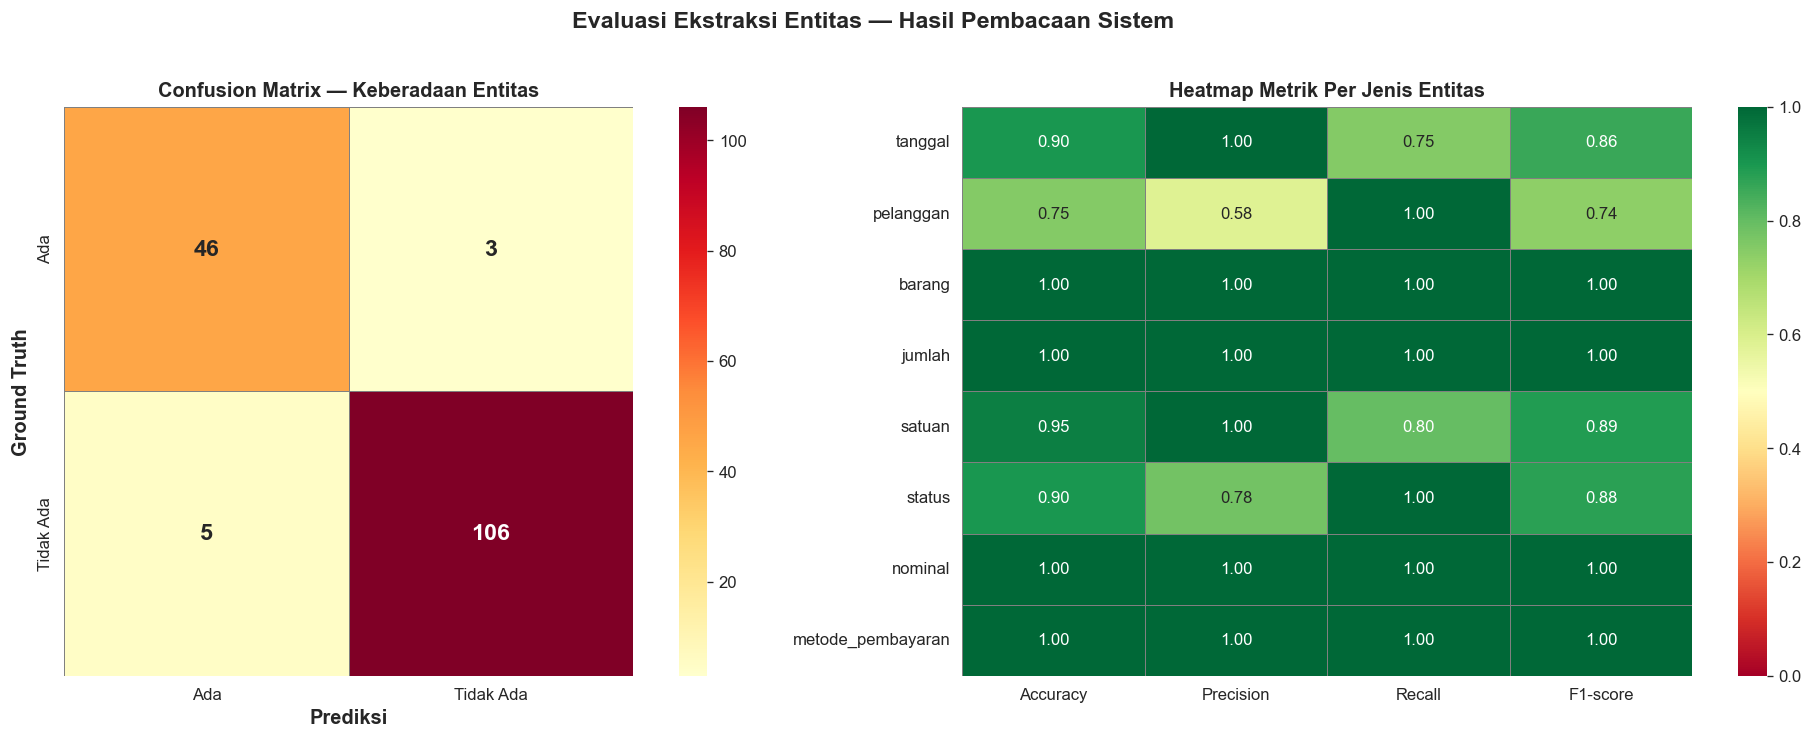

In [12]:
# Confusion Matrix Entitas (Ada vs Tidak_Ada)
cm_entity = confusion_matrix(match_gt_labels, match_pred_labels, labels=["Ada", "Tidak_Ada"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# --- Heatmap 1: Confusion Matrix Keberadaan Entitas ---
sns.heatmap(
    cm_entity,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=['Ada', 'Tidak Ada'],
    yticklabels=['Ada', 'Tidak Ada'],
    linewidths=0.5,
    linecolor='gray',
    square=True,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
    ax=axes[0]
)
axes[0].set_xlabel('Prediksi', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix — Keberadaan Entitas', fontsize=12, fontweight='bold')

# --- Heatmap 2: Metrik per jenis entitas ---
entity_names = [m['Entitas'] for m in per_entity_metrics]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
heat_data = np.array([
    [m['Accuracy'], m['Precision'], m['Recall'], m['F1-score']]
    for m in per_entity_metrics
])

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    xticklabels=metric_names,
    yticklabels=entity_names,
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'fontsize': 10},
    ax=axes[1]
)
axes[1].set_title('Heatmap Metrik Per Jenis Entitas', fontsize=12, fontweight='bold')
axes[1].set_yticklabels(entity_names, rotation=0)

plt.suptitle('Evaluasi Ekstraksi Entitas — Hasil Pembacaan Sistem', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Ringkasan Hasil

In [13]:
# Tabel Ringkasan Hasil
summary_data = {
    'Komponen': ['Identifikasi Intent', 'Ekstraksi Entitas'],
    'Accuracy': [
        f"{intent_accuracy*100:.2f}%",
        f"{entity_accuracy*100:.2f}%"
    ],
    'Precision': [
        f"{intent_precision*100:.2f}%",
        f"{entity_precision*100:.2f}%"
    ],
    'Recall': [
        f"{intent_recall*100:.2f}%",
        f"{entity_recall*100:.2f}%"
    ],
    'F1-score': [
        f"{intent_f1*100:.2f}%",
        f"{entity_f1*100:.2f}%"
    ]
}

df_summary = pd.DataFrame(summary_data)

print("=" * 70)
print("RINGKASAN HASIL PENGUJIAN")
print("=" * 70)
print()
print("Seluruh nilai dihitung otomatis menggunakan sklearn.metrics")
print("berdasarkan hasil pembacaan sistem yang sebenarnya.")
print()
df_summary

RINGKASAN HASIL PENGUJIAN

Seluruh nilai dihitung otomatis menggunakan sklearn.metrics
berdasarkan hasil pembacaan sistem yang sebenarnya.



,Komponen,Accuracy,Precision,Recall,F1-score
0,Identifikasi Intent,95.00%,97.22%,94.44%,94.71%
1,Ekstraksi Entitas,93.75%,86.27%,93.62%,89.80%


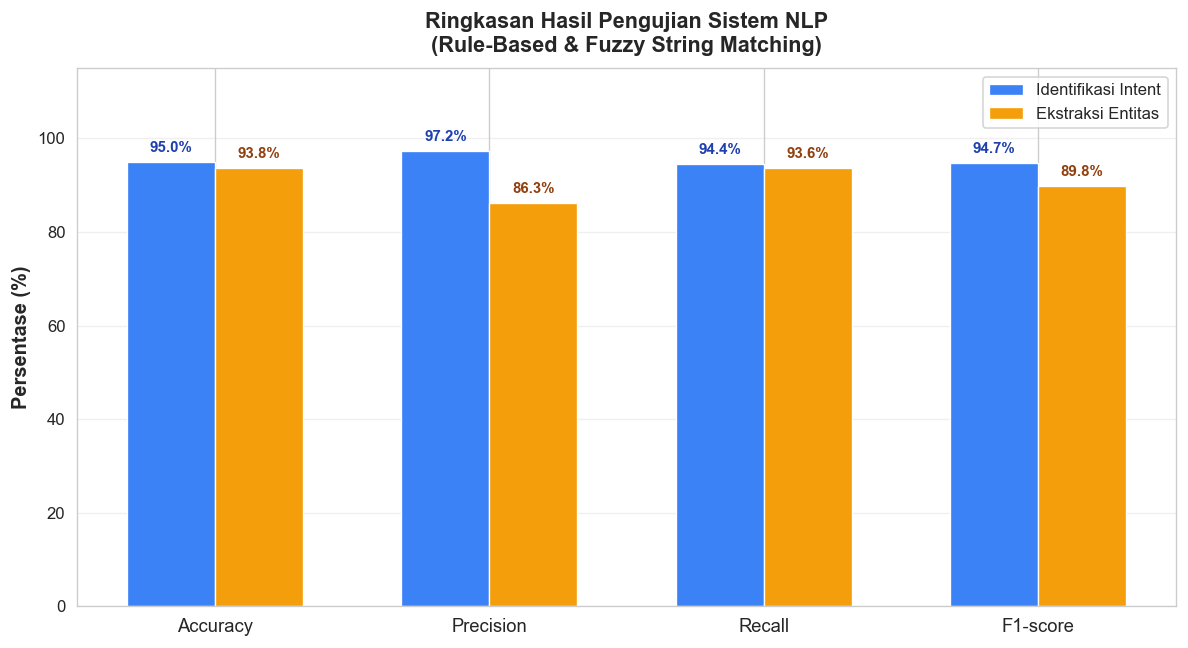

In [14]:
# Visualisasi Bar Chart Ringkasan
fig, ax = plt.subplots(figsize=(10, 5.5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
intent_vals = [intent_accuracy*100, intent_precision*100, intent_recall*100, intent_f1*100]
entity_vals = [entity_accuracy*100, entity_precision*100, entity_recall*100, entity_f1*100]

x = np.arange(len(metrics))
width = 0.32

bars1 = ax.bar(x - width/2, intent_vals, width, label='Identifikasi Intent',
               color='#3B82F6', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, entity_vals, width, label='Ekstraksi Entitas',
               color='#F59E0B', edgecolor='white', linewidth=0.8)

ax.set_ylabel('Persentase (%)', fontsize=12, fontweight='bold')
ax.set_title('Ringkasan Hasil Pengujian Sistem NLP\n(Rule-Based & Fuzzy String Matching)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)

# Label nilai di atas bar
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1E40AF')

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#92400E')

plt.tight_layout()
plt.show()

---
## 9. Kesimpulan

Kesimpulan dibuat **otomatis** berdasarkan hasil perhitungan evaluasi.

In [15]:
# ============================================================
# KESIMPULAN — Dibuat otomatis dari hasil perhitungan
# ============================================================

intent_benar = sum(1 for g, p in zip(gt_intents, pred_intents) if g == p)
intent_salah = len(gt_intents) - intent_benar

print("=" * 70)
print("KESIMPULAN")
print("=" * 70)

print(f"""
Hasil pengujian menunjukkan bahwa sistem NLP berbasis Rule-Based dan
Fuzzy String Matching berhasil mengidentifikasi intent dengan:
  - Accuracy  : {intent_accuracy*100:.2f}%
  - Precision : {intent_precision*100:.2f}%
  - Recall    : {intent_recall*100:.2f}%
  - F1-score  : {intent_f1*100:.2f}%

Dari {len(gt_intents)} data uji, {intent_benar} intent teridentifikasi dengan
benar dan {intent_salah} intent tidak sesuai dengan Ground Truth.

Pada ekstraksi entitas diperoleh:
  - Accuracy  : {entity_accuracy*100:.2f}%
  - Precision : {entity_precision*100:.2f}%
  - Recall    : {entity_recall*100:.2f}%
  - F1-score  : {entity_f1*100:.2f}%

Dari {total_pasangan} pasangan entitas (20 input × 8 jenis entitas),
{total_cocok} pasangan cocok secara exact match dan
{total_pasangan - total_cocok} pasangan tidak cocok.
  - TP (benar terdeteksi, nilai tepat) : {tp}
  - TN (benar tidak ada)               : {tn}
  - FP (salah mendeteksi)              : {fp}
  - FN (gagal mendeteksi)              : {fn}

Nilai tersebut diperoleh dari hasil pembacaan sistem secara langsung
tanpa adanya penyesuaian terhadap Ground Truth.""")

# Detail intent yang salah
salah_list = []
for i, (g, p) in enumerate(zip(gt_intents, pred_intents)):
    if g != p:
        salah_list.append((i+1, test_inputs[i], g, p))

if salah_list:
    print(f"\nDetail intent yang tidak sesuai ({len(salah_list)} kasus):")
    print("-" * 70)
    for no, inp, gt, pr in salah_list:
        inp_display = inp[:50] + '...' if len(inp) > 50 else inp
        print(f"  [{no:02d}] \"{inp_display}\"")
        print(f"       Ground Truth : {gt}")
        print(f"       Prediksi     : {pr}")

# Detail entitas yang salah
salah_entitas = [(r['No'], r['Input'], r['Entitas'], r['GT'], r['Pred'])
                 for r in detail_rows if r['Cocok'] == '❌']

if salah_entitas:
    print(f"\nDetail entitas yang tidak cocok ({len(salah_entitas)} pasangan):")
    print("-" * 70)
    for no, inp, ent, gt, pr in salah_entitas:
        print(f"  [{no:02d}] {ent:<20s}: GT={gt:<20s} Pred={pr}")

print("\n" + "=" * 70)
print("Seluruh proses pengujian dapat direproduksi dengan")
print("menjalankan ulang notebook ini di Jupyter Lab.")
print("=" * 70)

KESIMPULAN

Hasil pengujian menunjukkan bahwa sistem NLP berbasis Rule-Based dan
Fuzzy String Matching berhasil mengidentifikasi intent dengan:
  - Accuracy  : 95.00%
  - Precision : 97.22%
  - Recall    : 94.44%
  - F1-score  : 94.71%

Dari 20 data uji, 19 intent teridentifikasi dengan
benar dan 1 intent tidak sesuai dengan Ground Truth.

Pada ekstraksi entitas diperoleh:
  - Accuracy  : 93.75%
  - Precision : 86.27%
  - Recall    : 93.62%
  - F1-score  : 89.80%

Dari 160 pasangan entitas (20 input × 8 jenis entitas),
150 pasangan cocok secara exact match dan
10 pasangan tidak cocok.
  - TP (benar terdeteksi, nilai tepat) : 44
  - TN (benar tidak ada)               : 106
  - FP (salah mendeteksi)              : 7
  - FN (gagal mendeteksi)              : 3

Nilai tersebut diperoleh dari hasil pembacaan sistem secara langsung
tanpa adanya penyesuaian terhadap Ground Truth.

Detail intent yang tidak sesuai (1 kasus):
----------------------------------------------------------------------
